In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import time
import gget
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from tqdm import tqdm
import textwrap

import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from scvi.external import CellAssign

import cupy as cp
import cuml

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# Load anndata

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 337 ms, sys: 2.49 s, total: 2.83 s
Wall time: 41.2 s


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersio

# Load Capybara scores

In [3]:
%%time
# Load Capybara output
# fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/capybara_basename_scale.csv"
# fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/basename_simple_scale.csv"
fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/gomes_scale.csv"
df = pd.read_csv(fpath_scale)
print(f"{df.shape=}")
df.head()

df.shape=(15867, 8)
CPU times: user 15.9 ms, sys: 3.99 ms, total: 19.8 ms
Wall time: 53.7 ms


,cell_name,frxn_DAY2,frxn_DAY15,frxn_DAY25,frxn_HDF,frxn_UCB,Lagrangian,Error
0,AAACCCAAGGTTACCT-1,0.170040,0.109249,0.266619,0.078770,0.113233,0,2071.296376
1,AAACCCAAGTTGAAGT-1,0.223195,0.000000,0.303041,0.037694,0.138382,0,2133.284516
2,AAACCCAAGTTGTCGT-1,0.000000,0.224228,0.025084,0.293761,0.108289,0,2185.636131
3,AAACCCACAGAAGCGT-1,0.043624,0.131409,0.064179,0.392458,0.067310,0,2149.240481
4,AAACCCACAGGAGGTT-1,0.277574,0.217432,0.185719,0.001122,0.056457,0,1944.893864


In [4]:
# Set index to 'cell_name' for merging
df = df.set_index('cell_name')

# Sanity check: ensure all indices in df exist in adata.obs
common_cells = adata.obs.index.intersection(df.index)
print(f"Merging on {len(common_cells)} shared cells")

# Merge into adata.obs
adata.obs = adata.obs.join(df, how='left')  # 'left' keeps all cells in adata.obs

adata.obs.head()

Merging on 15867 shared cells


,batch,phase,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,mean_pseudotime,mean_order,nnz,frxn_DAY2,frxn_DAY15,frxn_DAY25,frxn_HDF,frxn_UCB,Lagrangian,Error
AAACCCAAGGTTACCT-1,hsc,G1,3679,8.210668,11202.0,9.323937,27.932512,37.752187,47.491519,60.382075,...,0.808782,0.0,3679,0.170040,0.109249,0.266619,0.078770,0.113233,0,2071.296376
AAACCCAAGTTGAAGT-1,hsc,G1,3987,8.291045,10579.0,9.266721,24.766046,32.867001,40.835618,53.313168,...,0.922000,7688.0,3987,0.223195,0.000000,0.303041,0.037694,0.138382,0,2133.284516
AAACCCAAGTTGTCGT-1,hsc,S,2585,7.857868,6735.0,8.815222,28.537491,37.371938,48.136600,63.533779,...,0.264203,9543.0,2585,0.000000,0.224228,0.025084,0.293761,0.108289,0,2185.636131
AAACCCACAGAAGCGT-1,hsc,G1,2358,7.765993,5416.0,8.597297,24.686115,34.785820,45.217873,60.672083,...,0.295864,15150.0,2358,0.043624,0.131409,0.064179,0.392458,0.067310,0,2149.240481
AAACCCACAGGAGGTT-1,hsc,G1,4997,8.516793,21937.0,9.995976,31.845740,40.552491,50.152710,63.440762,...,0.787087,6684.0,4995,0.277574,0.217432,0.185719,0.001122,0.056457,0,1944.893864


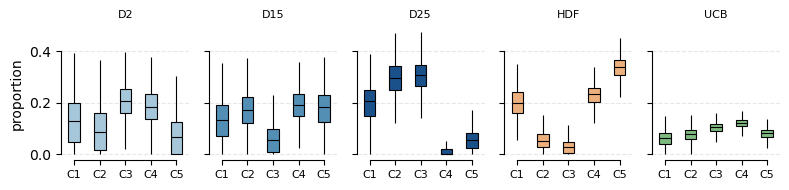

In [5]:
# Copy and melt
df = adata.obs.copy()
frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
df_melted = df.melt(
    id_vars=["cluster_str"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

df_melted['Cell Type'] = df_melted['Cell Type'].str.replace('frxn_', '').str.replace('DAY', 'D')
df_melted = df_melted.sort_values('Cell Type', ascending=False)

palette = {
    'D2': '#9ecae1',   # light blue
    'D15': '#4292c6',  # medium blue
    'D25': '#08519c',  # dark blue
    'HDF': '#fdae6b',  # orange
    'UCB': '#74c476'   # green
}


# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    col_wrap=5,
    sharey=True,
    height=2,
    aspect=0.8,
    col_order=['D2', 'D15', 'D25', 'HDF', 'UCB'],
)

g.map_dataframe(
    sns.boxplot,
    x="cluster_str",
    y="Fraction",
    hue='Cell Type',
    order=sorted(df["cluster_str"].unique()),
    width=0.45,
    linecolor='k',
    palette=palette,
    capprops={'linewidth': 0},  
    showfliers=False,
    linewidth=0.8
)

g.set_axis_labels("", "proportion")
g.set_titles(col_template="{col_name}", size=8)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
sns.despine(trim=True)
plt.show()


[<Axes: title={'center': 'D15 (CD49f+)'}, xlabel='FA1', ylabel='FA2'>,
 <Axes: title={'center': 'D25 (CD34+CD49f+)'}, xlabel='FA1', ylabel='FA2'>]

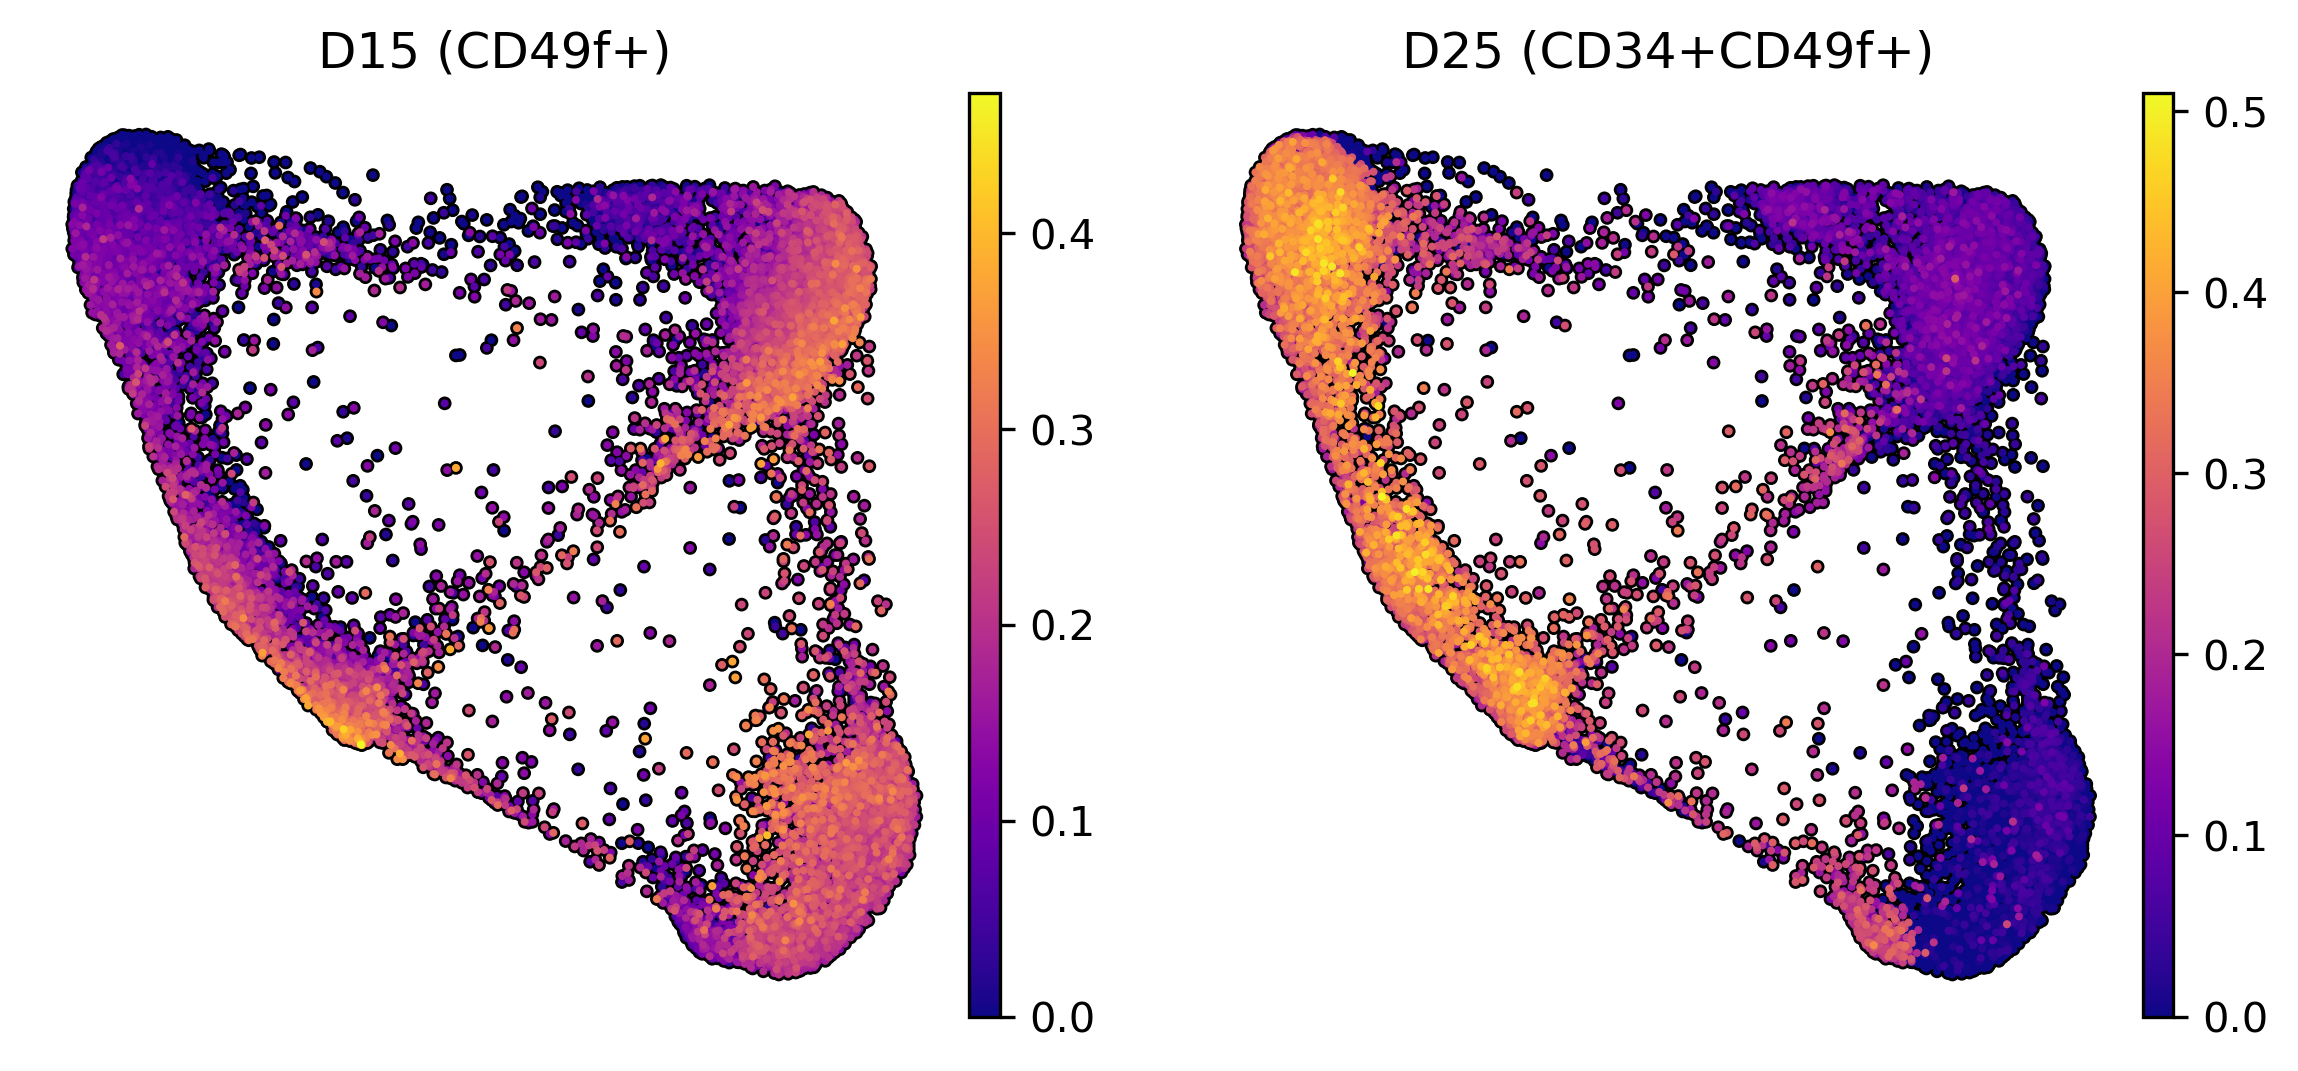

In [6]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['frxn_DAY15', 'frxn_DAY25'],
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    cmap='plasma',
    title=['D15 (CD49f+)', 'D25 (CD34+CD49f+)'],
    frameon=False,
    wspace=0.15,
    show=False, 
)

[<Axes: title={'center': 'D15 (CD49f+)'}, xlabel='FA1', ylabel='FA2'>,
 <Axes: title={'center': 'D25 (CD34+CD49f+)'}, xlabel='FA1', ylabel='FA2'>]

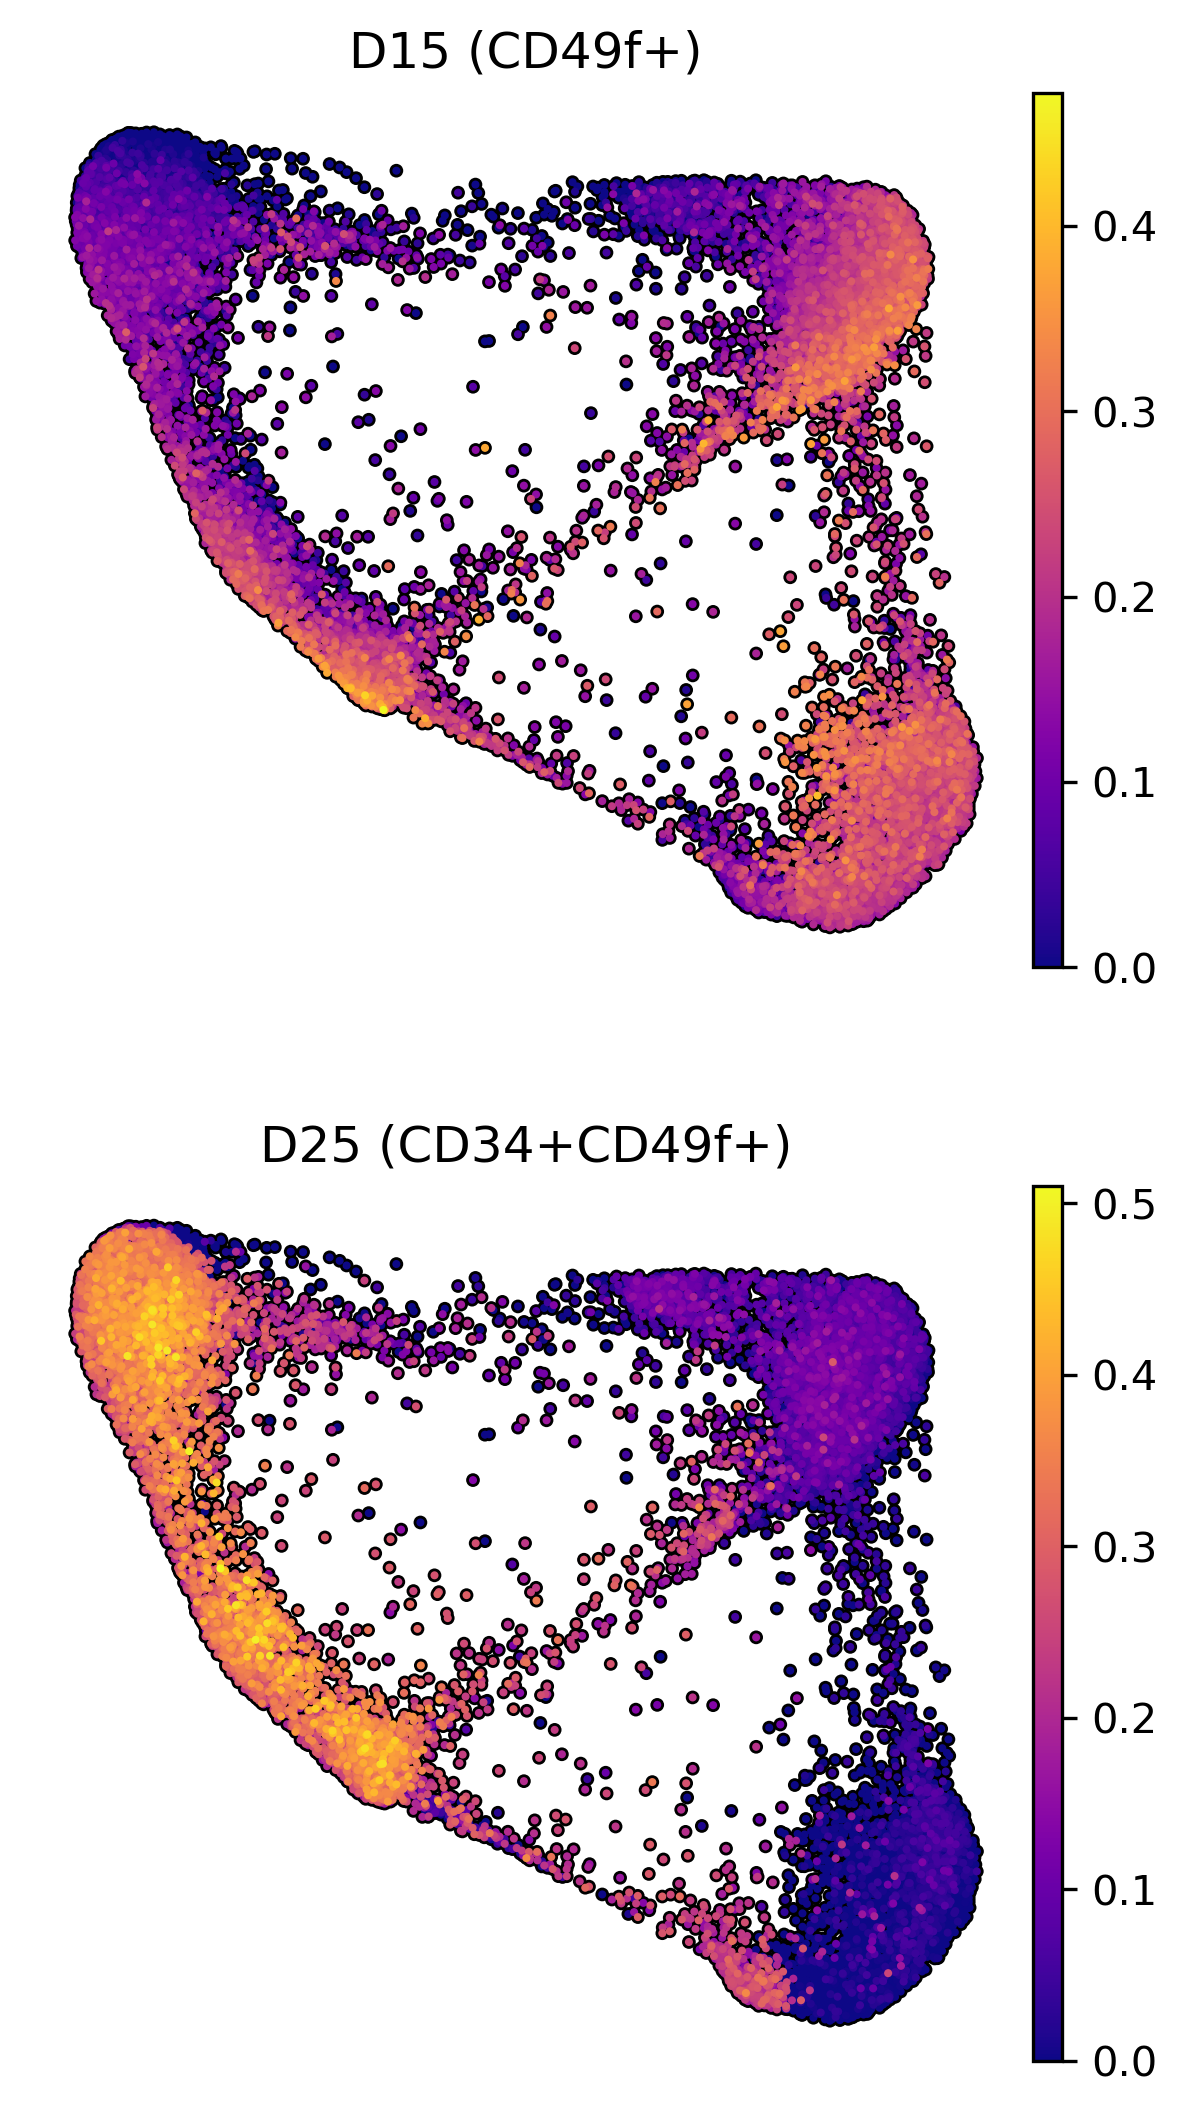

In [7]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['frxn_DAY15', 'frxn_DAY25'],
    size=15,
    ncols=1,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    cmap='plasma',
    title=['D15 (CD49f+)', 'D25 (CD34+CD49f+)'],
    frameon=False,
    wspace=0.15,
    show=False, 
)

In [8]:
# break

# Hybrid assignments

In [9]:
# Assign based on max fraction
frac_cols = [x for x in adata.obs.columns if 'frxn_' in x]
print(frac_cols)

# Relaxed threshold for hybrid assignment
hybrid_thresh = 0.2

def assign_relaxed_hybrid(row):
    # Get fractions above threshold
    above_thresh = row[row > hybrid_thresh].index.tolist()
    
    # Clean and format label
    if len(above_thresh) == 0:
        return "unassigned"
    
    clean_labels = [s.replace("frxn_", "").replace("_", " ") for s in above_thresh]
    return "+".join(sorted(clean_labels))

# Apply to obs
adata.obs['capybara_assignment'] = adata.obs[frac_cols].apply(assign_relaxed_hybrid, axis=1)

print(adata.obs['capybara_assignment'].value_counts().to_string())
print()

# Group and count
plot_df = (
    adata.obs
    .groupby(['cluster_str', 'capybara_assignment'])
    .size()
    .reset_index(name='count')
)

# Clean labels
plot_df['capybara_assignment'] = (
    plot_df['capybara_assignment']
    .str.replace("frxn_", "", regex=False)
    .str.replace("_", " ")
)

# Normalize to proportions within each cluster
plot_df['proportion'] = (
    plot_df
    .groupby('cluster_str')['count']
    .transform(lambda x: x / x.sum())
)
plot_df.head()

['frxn_DAY2', 'frxn_DAY15', 'frxn_DAY25', 'frxn_HDF', 'frxn_UCB']
capybara_assignment
DAY15+HDF           3716
HDF                 3295
DAY25               2877
DAY2+DAY25          2158
DAY2+HDF            1323
DAY15+DAY25          848
DAY2                 783
DAY15                306
unassigned           176
DAY25+HDF            130
DAY15+DAY2           115
DAY15+DAY2+HDF        78
DAY15+DAY25+HDF       21
UCB                   18
DAY2+DAY25+HDF         8
DAY15+DAY2+DAY25       6
DAY2+UCB               4
DAY15+UCB              4
HDF+UCB                1



/tmp/ipykernel_2653674/1075804446.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['cluster_str', 'capybara_assignment'])
/tmp/ipykernel_2653674/1075804446.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('cluster_str')['count']


,cluster_str,capybara_assignment,count,proportion
0,C1,DAY15,31,0.037170
1,C1,DAY15+DAY2,0,0.000000
2,C1,DAY15+DAY2+DAY25,0,0.000000
3,C1,DAY15+DAY2+HDF,2,0.002398
4,C1,DAY15+DAY25,49,0.058753


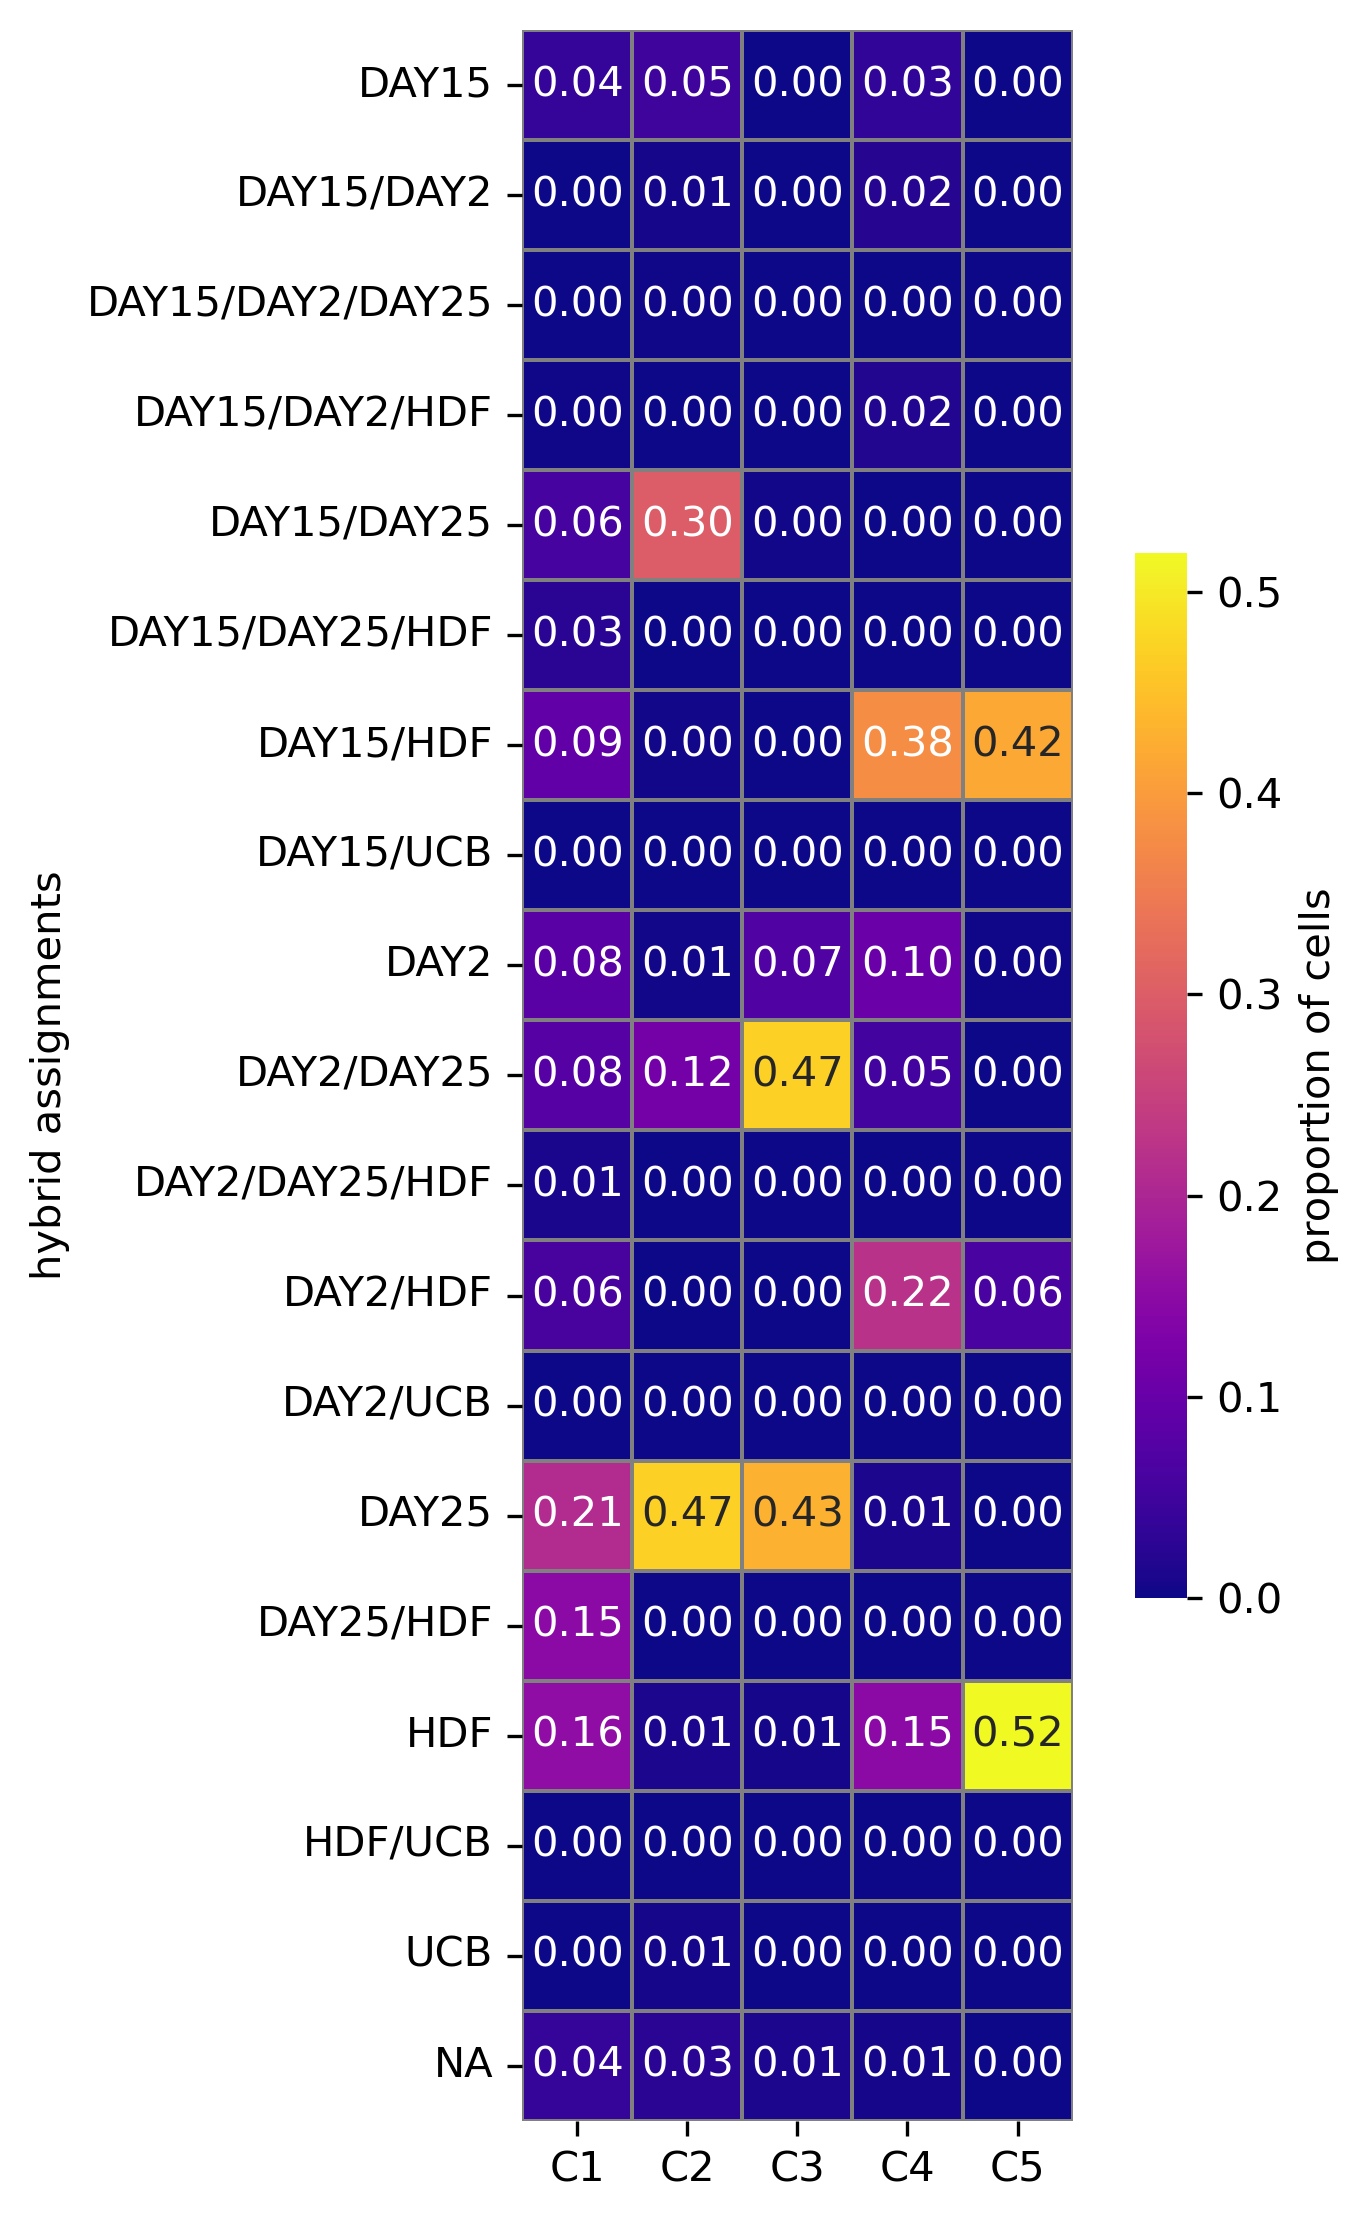

In [10]:
# Pivot to wide format: rows = assignment, columns = cluster, values = proportion
heat_df = plot_df.pivot(
    index='capybara_assignment',
    columns='cluster_str',
    values='proportion'
).fillna(0)


# Define abbreviations
abbrev_map = {
    'fibroblasts': 'Fib',
    'hematopoietic progenitors': 'HP',
    'endothelial cells': 'EC',
    'hsc': 'HSC',
    'unassigned': 'NA'
}

# Helper to rename full label to abbreviations and replace "+" with "/"
def abbreviate(label):
    parts = label.split('+')
    abbrev_parts = [abbrev_map.get(p.strip(), p.strip()) for p in parts]
    return '/'.join(abbrev_parts)

# Apply to index
heat_df.index = heat_df.index.map(abbreviate)


plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.75, 7.5

sns.heatmap(
    heat_df,
    cmap='plasma',
    linewidths=0.5,
    square=True,
    linecolor='gray',
    cbar_kws={'label': 'proportion of cells', 'shrink': 0.5},
    annot=True,
    fmt=".2f"
)

plt.xlabel("")
plt.ylabel("hybrid assignments")
plt.tight_layout()
plt.show()


In [ ]:
break

# Find the correlates

In [ ]:
# Extract gene expression matrix (assumes log-normalized)
X = adata.X
if not isinstance(X, np.ndarray):
    X = X.toarray()  # Convert sparse matrix to dense if needed

# Get gene names
gene_names = adata.var_names

# Extract cell-level fractions
obs_df = adata.obs[frxn_cols].copy()
assert obs_df.shape[0] == X.shape[0], "Mismatch in number of cells"

# Store results
results = []

print("Computing Spearman correlations...")
for frxn_col in tqdm(frxn_cols):
    for i, gene in enumerate(gene_names):
        rho, pval = spearmanr(X[:, i], obs_df[frxn_col])
        results.append({
            'Fraction Type': frxn_col,
            'Gene': gene,
            'SpearmanR': rho,
            'P-value': pval
        })

# Convert to DataFrame
cor_df = pd.DataFrame(results)

print('done!')


Computing Spearman correlations...


 60%|██████    | 3/5 [02:26<01:37, 48.86s/it]

In [ ]:
# For each fraction type, get top genes by absolute Spearman R
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]


# For each fraction type, get top genes by absolute Spearman R
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)
print(top_cor_df.to_string(index=False))

# Enrichment

In [ ]:
# For each fraction type, get top genes by absolute Spearman R
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]

# For each fraction type, get top genes by absolute Spearman R
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)

top_cor_df.head()

In [ ]:
# Filter significant correlations
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]

# Get top 15 genes by Fraction Type
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)

for frac_type, group in top_cor_df.groupby('Fraction Type'):
    genes = group['Gene'].head(100).tolist()
    edf = gget.enrichr(genes, database="ontology")
    edf['genes'] = edf['overlapping_genes'].apply(lambda x: ",".join(x))
    edf = edf[['path_name', 'adj_p_val', 'genes']]
    print("=" * 20, f"{frac_type}", "=" * 20)
    print(edf.head(10).to_string(index=False))

    edf['log_adj_p'] = -np.log10(edf['adj_p_val'].clip(lower=1e-300))
    edf['path_name_wrapped'] = edf['path_name'].apply(lambda x: '\n'.join(textwrap.wrap(x, width=60)))

    # Barplot
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['figure.figsize'] = 4, 4
    sns.barplot(
        data=edf.head(15),
        y='path_name_wrapped',
        x='log_adj_p',
        ec='k',
        color='lightgrey',
        linewidth=0.75,
        width=0.5,
    )
    plt.xlabel('-log10(Adjusted P-value)')
    plt.ylabel('')
    plt.yticks(fontsize=6)
    plt.title(frac_type)
    sns.despine(trim=True)
    plt.show()

# Plotting

In [ ]:
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf[pdf['Fraction Type'] == 'frxn_endothelial_cells'].sort_values('SpearmanR', ascending=False).head(25)

In [ ]:

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

color = [
    'SERPINE1', 'HIP1', 'AHNAK2',
    'MAGI2', 'GAS7', 'YWHAZ',
]

sc.pl.draw_graph(
    adata, 
    color=color,
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.15,
)


In [ ]:
# For each fraction type, get top genes by absolute Spearman R
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]


labels = {
    'frxn_endothelial_cells': 'Endothelial Cells',
    'frxn_fibroblasts': 'Fibroblasts',
    'frxn_hematopoietic_progenitors': 'Progenitors',
    'frxn_hsc': 'HSCs'
}


# For each fraction type, get top genes by absolute Spearman R
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)
top_cor_df['label'] = top_cor_df['Fraction Type'].map(labels)

for group, group_df in top_cor_df.groupby(['label']):

    frxn_type = group_df['Fraction Type'].unique()[0]
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['figure.figsize'] = 4, 4

    sc.pl.draw_graph(
        adata, 
        color=[frxn_type] + group_df['Gene'].head(8).to_list(),
        size=25,
        ncols=3,
        alpha=1,
        use_raw=False,
        add_outline=True,
        outline_color=('k', 'k'),
        title=[group[0]] + group_df['Gene'].head(8).to_list(),
        frameon=False,
        wspace=0.15,
        show=False, 
    )

    plt.suptitle(f"{group[0]} correlates", fontsize=14)
    plt.show()    